# Dirty Cafe Sales - Exploratory Data Analysis

**Dataset:** `dirty_cafe_clean.csv` (output from the data cleaning notebook)  
**Goal:** Answer specific business questions about café sales, revenue, and customer behavior.

---

EDA isn't just about making charts — it's about asking the right questions first, then letting the data answer them.  
Every visualization in this notebook has a reason. The reason comes before the code.

## 1. Import Libraries

Adding `matplotlib` and `seaborn` on top of the cleaning dependencies.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cleaner chart style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

## 2. Load the Cleaned Dataset

I'm loading from the cleaned file - not the raw one. The cleaning notebook already standardized missing values and fixed data types, so the data I load here should be ready to work with.

In [4]:
df = pd.read_csv('dirty_cafe_clean.csv')

# Transaction Date needs to be re-parsed since CSV doesn't preserve datetime dtype
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 19)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,location_raw,location_missing,Item_raw,Item_missing,Payment Method_raw,Payment Method_missing,Quantity_raw,price_per_unit_raw,Total_spent_raw,Transaction_Date_raw,Total_mismatch
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,Takeaway,0,Coffee,0,Credit Card,0,2,2.0,4.0,2023-09-08,0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,In-store,0,Cake,0,Cash,0,4,3.0,12.0,2023-05-16,0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,In-store,0,Cookie,0,Credit Card,0,4,1.0,ERROR,2023-07-19,0
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27,UNKNOWN,1,Salad,0,UNKNOWN,1,2,5.0,10.0,2023-04-27,0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,In-store,0,Coffee,0,Digital Wallet,0,2,2.0,4.0,2023-06-11,0


In [5]:
# Confirm data types look right before starting
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Transaction ID          10000 non-null  str           
 1   Item                    9031 non-null   str           
 2   Quantity                9521 non-null   float64       
 3   Price Per Unit          9467 non-null   float64       
 4   Total Spent             9960 non-null   float64       
 5   Payment Method          6822 non-null   str           
 6   Location                6039 non-null   str           
 7   Transaction Date        9540 non-null   datetime64[us]
 8   location_raw            6735 non-null   str           
 9   location_missing        10000 non-null  int64         
 10  Item_raw                9667 non-null   str           
 11  Item_missing            10000 non-null  int64         
 12  Payment Method_raw      7421 non-null   str           
 13

## 3. Define the Questions

I don't start with charts. I start with questions that a café owner would actually care about.

1. How much total revenue does the café generate?
2. How many valid transactions are there?
3. Which items are sold most frequently?
4. Which items generate the most revenue?
5. How do customers prefer to pay?
6. How does missing data affect the analysis?

Each question maps to a specific column or set of columns. Each calculation only drops rows where the required column is missing - nothing else.

---

## 4. KPI 1 - Total Revenue

**Question:** How much total money has the café made?

**Required column:** `Total Spent`  
**Decision:** Drop only rows where `Total Spent` is missing, since you can't count revenue without it.

This isn't a permanent deletion - I'm filtering for this specific calculation only.

In [6]:
revenue_df = df.dropna(subset=['Total Spent'])

total_revenue = revenue_df['Total Spent'].sum()
print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹88,952.00


## 5. KPI 2 - Total Valid Transactions

**Question:** How many transactions have usable revenue data?

This number is the denominator for any revenue-based percentage I calculate later. It's also important for transparency - I want to be clear about how much of the dataset I'm actually using.

In [7]:
valid_transactions = revenue_df.shape[0]
total_transactions = df.shape[0]

print(f"Valid transactions (Total Spent present): {valid_transactions:,}")
print(f"Total rows in dataset: {total_transactions:,}")
print(f"Coverage: {valid_transactions / total_transactions * 100:.1f}%")

Valid transactions (Total Spent present): 9,960
Total rows in dataset: 10,000
Coverage: 99.6%


## 6. KPI 3 - Sales Count by Item

**Question:** Which items are ordered most often?

**Required column:** `Item`  
**Decision:** Drop rows where `Item` is missing - can't count sales for an unknown item.

Note: This tells me about *popularity*, not profit. An item can be ordered a lot while still generating low revenue if it's cheap.

In [8]:
item_df = df.dropna(subset=['Item'])

item_count = item_df['Item'].value_counts()
print("Sales count by item:")
print(item_count)

Sales count by item:
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64


## 7. KPI 4 - Revenue by Item

**Question:** Which items actually make the café the most money?

**Required columns:** `Item` and `Total Spent`  
**Decision:** Drop rows where either column is missing.

This is different from sales count. A high-selling item isn't necessarily a high-revenue item.

In [9]:
item_revenue_df = df.dropna(subset=['Item', 'Total Spent'])

item_revenue = item_revenue_df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)
print("Revenue by item:")
print(item_revenue)

Revenue by item:
Item
Salad       17320.0
Sandwich    13664.0
Smoothie    13320.0
Juice       10509.0
Cake        10395.0
Coffee       7062.0
Tea          4951.5
Cookie       3223.0
Name: Total Spent, dtype: float64


## 8. KPI 5 - Payment Method Distribution

**Question:** How do customers prefer to pay?

**Required column:** `Payment Method`  
**Important caveat:** About a third of all transactions don't have a payment method recorded.  
The results here only reflect what's available - they may not represent the full customer base.

In [10]:
payment_df = df.dropna(subset=['Payment Method'])

payment_count = payment_df['Payment Method'].value_counts()
print("Payment method counts (known transactions only):")
print(payment_count)
print(f"\nTransactions with payment method missing: {df['Payment Method'].isna().sum():,}")
print(f"({df['Payment Method'].isna().mean() * 100:.1f}% of total)")

Payment method counts (known transactions only):
Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64

Transactions with payment method missing: 3,178
(31.8% of total)


---

## 9. Initial Observations

Before drawing charts, here's what the numbers are telling me:

- **Total revenue:** ~₹88,952 across ~9,960 valid transactions
- **Most popular items:** Juice and Coffee top the sales count, but the gap between items is small - all eight items have similar order frequencies
- **Highest revenue items:** Salad and Sandwich lead by a wide margin, despite not being the most frequently ordered
- **Payment methods:** Roughly equal split across Digital Wallet, Credit Card, and Cash - no strong preference visible in the available data
- **Data quality concern:** ~32% of transactions are missing a payment method, which limits how much we can trust the payment analysis

---

## 10. Visual Analysis

### Chart 1 - Revenue by Item

**Why this chart:** Sales volume alone doesn't tell the business where money is coming from. A café that wants to grow revenue needs to know which items are actually worth promoting.

**What to look for:** Is Salad really earning more than Coffee, even if Coffee is ordered more often? That would suggest price difference matters a lot.

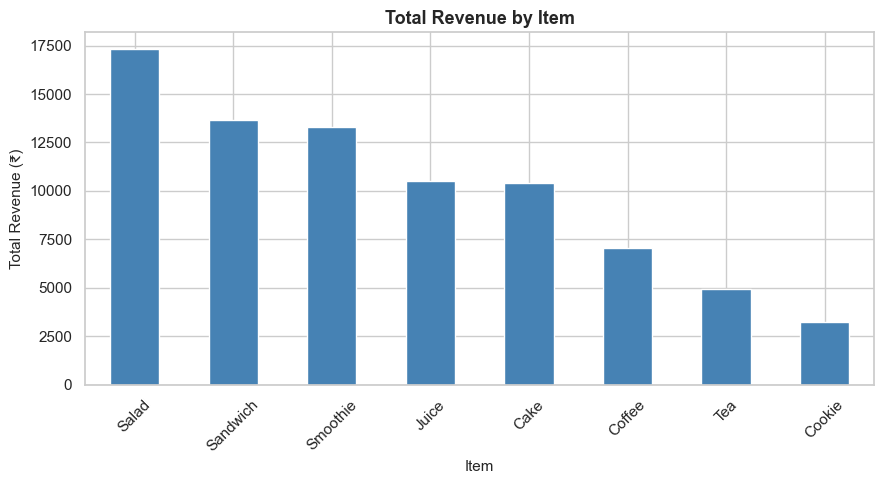

In [12]:
item_revenue = (
    df.dropna(subset=['Item', 'Total Spent'])
      .groupby('Item')['Total Spent']
      .sum()
      .sort_values(ascending=False)
)

fig, ax = plt.subplots()
item_revenue.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Total Revenue by Item', fontsize=13, fontweight='bold')
ax.set_xlabel('Item', fontsize=11)
ax.set_ylabel('Total Revenue (₹)', fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('screenshots/revenue_by_item.png', dpi=150)
plt.show()

**Insight:** Salad and Sandwich are the top revenue generators, well ahead of Coffee and Tea. This is likely a price effect - food items cost more per unit, so even similar sales volumes translate to higher revenue. If the café wants to grow revenue quickly, pushing food items over drinks makes sense.

### Chart 2 - Sales Count by Item

**Why this chart:** Frequency shows what customers actually like ordering - regardless of price. This is useful for staffing, inventory planning, and menu placement.

**What to look for:** Compare this to the revenue chart. Are the most ordered items also the highest earners?

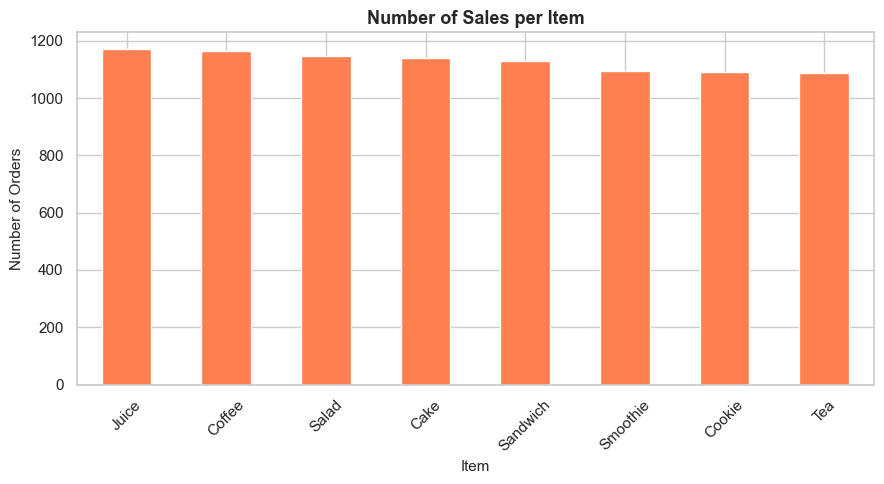

In [13]:
item_count = (
    df.dropna(subset=['Item'])
      ['Item']
      .value_counts()
)

fig, ax = plt.subplots()
item_count.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Number of Sales per Item', fontsize=13, fontweight='bold')
ax.set_xlabel('Item', fontsize=11)
ax.set_ylabel('Number of Orders', fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('screenshots/sales_count_by_item.png', dpi=150)
plt.show()

**Insight:** All items have a similar order frequency - Juice leads slightly, but the spread is narrow (1,089 to 1,171 orders). This is quite balanced. It means customers order all menu items fairly evenly, and no single item dominates in terms of popularity. Compare this to the revenue chart: Salad and Sandwich are not the most ordered items, but they earn the most. The difference comes entirely from pricing.

### Chart 3 - Payment Method Distribution

**Why this chart:** Knowing how customers prefer to pay is useful for operations - it helps decide whether to invest in specific payment terminals, offer discounts for certain methods, or plan for cash handling.

**Caveat:** Remember that ~32% of transactions don't have a payment method recorded. This chart only reflects the transactions where payment data exists.

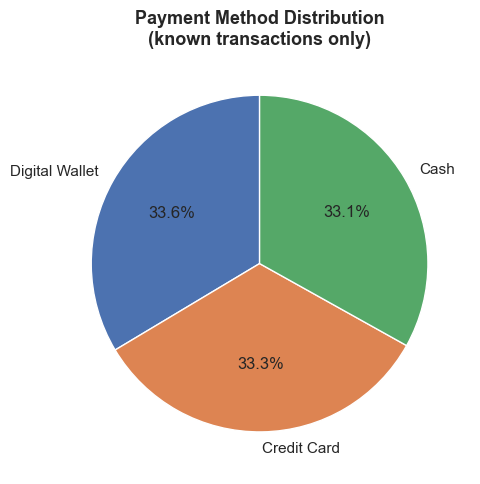

In [14]:
payment_count = df.dropna(subset=['Payment Method'])['Payment Method'].value_counts()

fig, ax = plt.subplots()
payment_count.plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=ax,
    colors=['#4C72B0', '#DD8452', '#55A868'],
    startangle=90
)
ax.set_title('Payment Method Distribution\n(known transactions only)', fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('screenshots/payment_method_distribution.png', dpi=150)
plt.show()

**Insight:** Among transactions where payment was recorded, all three methods - Digital Wallet, Credit Card, and Cash - are used almost equally (roughly 33% each). There's no dominant preference. This could mean the café has a diverse customer base, or simply that the missing data is masking a real preference. Without filling that 32% gap, we can't say definitively.

### Chart 4 - Missing Payment Method Impact

**Why this chart:** Before drawing conclusions from the payment analysis, I need to show how much data is actually missing. This chart makes the data quality issue visible - which is especially important if this notebook is shared with stakeholders.

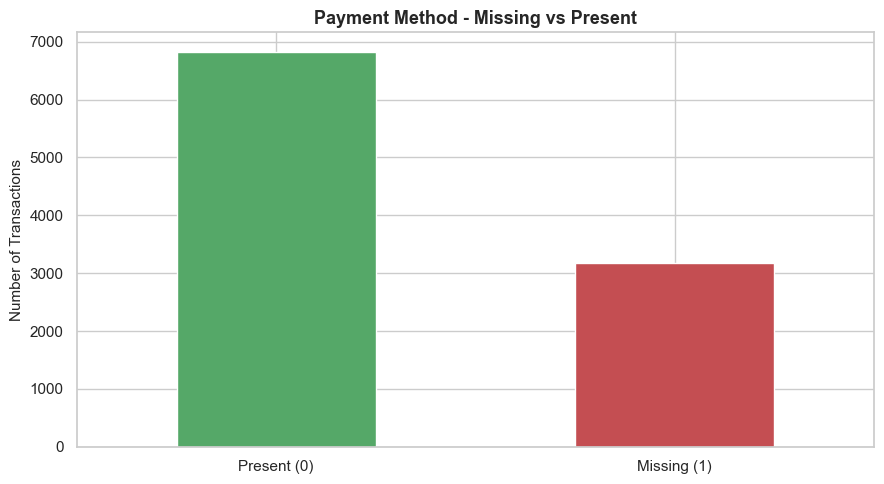

Present: 6,822
Missing: 3,178


In [16]:
fig, ax = plt.subplots()
missing_counts = df['Payment Method_missing'].value_counts().sort_index()
missing_counts.index = ['Present (0)', 'Missing (1)']
missing_counts.plot(
    kind='bar',
    ax=ax,
    color=['#55A868', '#C44E52'],
    edgecolor='white'
)
ax.set_title('Payment Method - Missing vs Present', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Number of Transactions', fontsize=11)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('screenshots/missing_payment_method.png', dpi=150)
plt.show()

print(f"Present: {missing_counts.iloc[0]:,}")
print(f"Missing: {missing_counts.iloc[1]:,}")

**Insight:** Over 3,000 transactions - about 32% of the entire dataset - have no payment method recorded. This is a significant gap. Any conclusions drawn from the payment analysis should come with this caveat: we're only looking at two-thirds of transactions. If the missing data is not random (e.g., a specific location or time period stopped recording payment methods), the pie chart above could be misleading.

---

## 11. Summary of Findings

### Revenue
- The café generated approximately **₹88,952** in total revenue across **9,960 valid transactions**.
- Revenue is not evenly distributed across items.

### Product Performance
| Metric | Top Item | Notes |
|---|---|---|
| Sales volume | Juice (1,171 orders) | All items within ~100 orders of each other |
| Revenue | Salad (₹17,320) | More than 5× higher than Cookie |

**Key takeaway:** Salad and Sandwich earn the most revenue despite not being the most ordered items. This is a pricing effect - food items command a higher price per unit than drinks. Promoting food items would likely have a bigger revenue impact than pushing drinks.

### Customer Behaviour
- Among the ~68% of transactions with payment data: Digital Wallet, Credit Card, and Cash are split almost evenly.
- No strong preference for any single payment method.

### Data Quality
- ~32% of transactions are missing payment method - too large to ignore.
- ~10% of transactions are missing item name.
- Missing data was made explicit during cleaning (not silently dropped), which means the gaps are measurable.

### What Would Improve This Analysis
- Fixing the missing payment method data would allow a proper payment preference analysis.
- Adding date filtering would let us look at trends over time (e.g., peak hours, seasonal items).
- Location data (In-store vs Takeaway) could reveal whether ordering behavior differs by channel.